# Understanding and Predicting Severe Traffic Accidents in the UK:  A Statistical and Machine Learning Perspective for Road Safety Improvement



Preparation

Github link: [https://github.com/ukilay/DS.git]

Number of words: 1584

Runtime: Notebook executed in 1 minutes and 42.45 seconds. 

Coding environment: SDS Docker

Additional library [libraries not included in SDS Docker or not used in this module]:

**contextily**: used for adding contextual basemaps to geographic plots.

**imbalanced-learn**: used to perform resampling techniques such as SMOTE (Synthetic Minority Oversampling Technique) to address class imbalance in the dataset.

**kaleido**: is a lightweight package used by Plotly to export interactive figures as static image files like PNG, SVG, and PDF.

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)




## 1. Introduction

[[ go back to the top ]](#Table-of-contents)

Road traffic accidents pose a persistent public safety challenge, particularly when they result in severe outcomes. Prior research has shown that serious accidents are not randomly distributed; rather, they often cluster in time and space, aligning with peak traffic hours and specific road types (Sufian, Varadarajan and Niu, 2024). Moreover, injury severity has been found to correlate with both environmental and behavioral factors, including road layout, lighting, weather, driver age, and maneuver type (Sze and Wong, 2007; Savolainen et al., 2011). These findings highlight the need for further empirical analysis to identify when and where major incidents occur and which specific factors statistically influence accident severity.

In recent years, machine learning approaches have been increasingly adopted to predict accident outcomes, offering improved flexibility over traditional regression models (Pourroostaei Ardakani et al., 2023). However, class imbalance and incomplete behavioral records remain common limitations, often reducing model effectiveness (Sufian, Varadarajan and Niu, 2024). This study builds on these insights to evaluate the predictive performance of Logistic Regression, Random Forest, and XGBoost models using UK Road Safety Data from 2023, addressing whether accident severity can be accurately predicted and which model and factors offer the most insight.


## 2. Research questions

[[ go back to the top ]](#Table-of-contents)

**RQ 1**: Do serious road traffic accidents in the UK show distinct patterns across time (e.g., hour of day, day of week, month) and space (e.g., urban vs. rural areas, road types)?

**RQ 2**: Which environmental (e.g., weather, lighting, road surface) and behavioral (e.g., vehicle manoeuvre, driver direction, sex and age of driver) factors are statistically associated with accident severity?

**RQ 3**: Can machine learning models effectively predict the severity of road traffic accidents using both environmental and behavioral factors? Which model performs best, and what is the relative importance of each factor?


## 3. Data

[[ go back to the top ]](#Table-of-contents)

The analysis draws on the UK Road Safety Data, specifically the “Road Safety Data – Vehicles 2023” and “Road Safety Data – Collisions 2023” datasets. These datasets provide detailed records of all reported road traffic accidents in the UK during 2023, including vehicle-level characteristics and collision-specific information. The data cover a range of variables such as environmental conditions, road types, vehicle maneuvers, and driver demographics. This study focuses on examining how selected environmental and behavioral features are associated with the severity of road traffic accidents.

### 3.1 Data Loading and Initial Inspection

**Note on Required libraries**

Before running the analysis, please ensure that the following Python packages are installed:

**contextily**: used for adding contextual basemaps to geographic plots.

**imbalanced-learn**: used to perform resampling techniques such as SMOTE (Synthetic Minority Oversampling Technique) to address class imbalance in the dataset.

**kaleido**: is a lightweight package used by Plotly to export interactive figures as static image files like PNG, SVG, and PDF.


You can install them using the following commands:

In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -U kaleido

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install contextily

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Step 0: Import packages
import warnings

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")

# Step 1: Load the dataset
url_collision = "https://raw.githubusercontent.com/ukilay/DS/main/dft-road-casualty-statistics-collision-2023.csv"
url_vehicle = "https://raw.githubusercontent.com/ukilay/DS/main/dft-road-casualty-statistics-vehicle-2023.csv"

collision = pd.read_csv(url_collision)
vehicle = pd.read_csv(url_vehicle)

print("Raw data shape:", collision.shape)
print("Raw data shape:", vehicle.shape)

# Step 2: Basic data inspection
display(collision.head())
collision.info()
display(vehicle.head())
vehicle.info()

Raw data shape: (104258, 37)
Raw data shape: (189815, 34)


,accident_index,accident_year,accident_reference,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,accident_severity,number_of_vehicles,...,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision
0,2023010419171,2023,10419171,525060.0,170416.0,-0.202878,51.418974,1,3,1,...,4,8,2,0,0,1,1,2,E01003383,-1
1,2023010419183,2023,10419183,535463.0,198745.0,-0.042464,51.671155,1,3,3,...,4,1,1,0,0,1,1,2,E01001547,-1
2,2023010419189,2023,10419189,508702.0,177696.0,-0.435789,51.487777,1,3,2,...,4,1,1,0,0,1,1,2,E01002448,-1
3,2023010419191,2023,10419191,520341.0,190175.0,-0.263972,51.597575,1,3,2,...,4,9,1,0,0,1,1,2,E01000129,-1
4,2023010419192,2023,10419192,527255.0,176963.0,-0.168976,51.477324,1,3,2,...,4,1,1,0,0,1,1,2,E01004583,-1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104258 entries, 0 to 104257
Data columns (total 37 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   accident_index                               104258 non-null  object 
 1   accident_year                                104258 non-null  int64  
 2   accident_reference                           104258 non-null  object 
 3   location_easting_osgr                        104246 non-null  float64
 4   location_northing_osgr                       104246 non-null  float64
 5   longitude                                    104246 non-null  float64
 6   latitude                                     104246 non-null  float64
 7   police_force                                 104258 non-null  int64  
 8   accident_severity                            104258 non-null  int64  
 9   number_of_vehicles                           104258 non-nul

,accident_index,accident_year,accident_reference,vehicle_reference,vehicle_type,towing_and_articulation,vehicle_manoeuvre,vehicle_direction_from,vehicle_direction_to,vehicle_location_restricted_lane,...,generic_make_model,driver_imd_decile,driver_home_area_type,lsoa_of_driver,escooter_flag,dir_from_e,dir_from_n,dir_to_e,dir_to_n,driver_distance_banding
0,2023010419171,2023,10419171,1,11,0,4,1,5,0,...,ALEXANDER DENNIS MODEL MISSING,3,1,E01001177,0,NaN,NaN,NaN,NaN,2
1,2023010419183,2023,10419183,1,11,0,18,5,1,0,...,WRIGHTBUS GEMINI,6,1,E01001419,0,NaN,NaN,NaN,NaN,2
2,2023010419183,2023,10419183,2,9,0,9,1,6,0,...,TOYOTA YARIS,3,1,E01001546,0,NaN,NaN,NaN,NaN,1
3,2023010419183,2023,10419183,3,9,0,8,7,1,0,...,BMW 2 SERIES,4,1,E01001686,0,NaN,NaN,NaN,NaN,4
4,2023010419189,2023,10419189,1,9,0,18,7,3,0,...,LEXUS RX 400,5,1,E01002443,0,NaN,NaN,NaN,NaN,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189815 entries, 0 to 189814
Data columns (total 34 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   accident_index                    189815 non-null  object 
 1   accident_year                     189815 non-null  int64  
 2   accident_reference                189815 non-null  object 
 3   vehicle_reference                 189815 non-null  int64  
 4   vehicle_type                      189815 non-null  int64  
 5   towing_and_articulation           189815 non-null  int64  
 6   vehicle_manoeuvre                 189815 non-null  int64  
 7   vehicle_direction_from            189815 non-null  int64  
 8   vehicle_direction_to              189815 non-null  int64  
 9   vehicle_location_restricted_lane  189815 non-null  int64  
 10  junction_location                 189815 non-null  int64  
 11  skidding_and_overturning          189815 non-null  i

### 3.2 Data Integration and Preprocessing



In [5]:
# Step 3: Keep only relevant variables
vehicle_selected = vehicle[[
    'accident_index',
    'vehicle_manoeuvre',
    'vehicle_direction_from',
    'vehicle_direction_to',
    'sex_of_driver',
    'age_band_of_driver'
]]

collision_to_drop = [
    "accident_year", "accident_reference", "location_easting_osgr",
    "location_northing_osgr", "local_authority_ons_district",
    "local_authority_highway", "first_road_number", "second_road_number",
    "lsoa_of_accident_location", "trunk_road_flag",
    "did_police_officer_attend_scene_of_accident", "enhanced_severity_collision"
]
cols_to_keep = ['accident_index']
collision_to_drop = [col for col in collision_to_drop if col not in cols_to_keep]
collision.drop(columns=[c for c in collision_to_drop if c in collision.columns], inplace=True)

# Step 4: Merge datasets on accident_index (one-to-many merge)
vehicle_selected = vehicle_selected.drop_duplicates(subset='accident_index', keep='first')
merged = pd.merge(collision, vehicle_selected, on='accident_index', how='left')
print("Merged shape:", merged.shape)

# Step 5: Drop rows missing 'date' or 'time' (needed for timestamp creation)
merged.dropna(subset=['date', 'time'], inplace=True)

# Step 6: Remove invalid coded values (-1) for categorical columns
invalid_code_columns = [
    'first_road_class', 'second_road_class', 'road_type', 'junction_detail',
    'junction_control', 'pedestrian_crossing_human_control',
    'pedestrian_crossing_physical_facilities', 'light_conditions',
    'weather_conditions', 'road_surface_conditions', 'special_conditions_at_site',
    'carriageway_hazards', 'urban_or_rural_area',
    'vehicle_manoeuvre', 'vehicle_direction_from', 'vehicle_direction_to',
    'sex_of_driver', 'age_band_of_driver'
]

# Convert to numeric and filter out -1
for col in invalid_code_columns:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
    merged = merged[merged[col] != -1]

# Step 7: Drop any remaining rows with missing values (after full structure is known)
original_rows = merged.shape[0]
merged.dropna(inplace=True)
print(f"Step 6: Dropped {original_rows - merged.shape[0]} rows with missing values.")

# Step 8: Check for duplicates
print("Step 7: Any duplicates?", merged.duplicated().any())

print("Merged shape:", merged.shape)

Merged shape: (104258, 30)
Step 6: Dropped 6276 rows with missing values.
Step 7: Any duplicates? False
Merged shape: (46315, 30)


### 3.3 Timestamp Creation and Temporal Feature Extraction

In [6]:
# Step 9: Create timestamp and extract month/hour
merged["time_stamp"] = pd.to_datetime(
    merged["date"] + " " + merged["time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)
merged.dropna(subset=["time_stamp"], inplace=True)
merged["month"] = merged["time_stamp"].dt.month
merged["hour"] = merged["time_stamp"].dt.hour

# This step is essential for capturing temporal patterns in accident occurrences.
#  By converting date and time into a unified timestamp and extracting 
# the corresponding month and hour, we enable subsequent analyses of 
# seasonal and hourly trends in accident severity.

### 3.4 Target Variable Definition and Categorical Encoding

In this step, the binary target variable major_incident is defined, where accidents classified as either Fatal (accident_severity = 1) or Serious (accident_severity = 2) are labeled as major incidents (1), and others as non-major (0). This variable will serve as the outcome in subsequent predictive analyses.

Additionally, all relevant categorical features—including environmental, temporal, and driver-related variables—are encoded using one-hot encoding to prepare the dataset for machine learning models.

In [7]:
# Step 10: Create custom binary target
merged["major_incident"] = merged.apply(
    lambda row: 1 if row["accident_severity"] in [1, 2] else 0,
    axis=1,
)

In [8]:
# Step 10: Define categorical columns (updated to match merged dataset)
cat_cols = [
    "day_of_week",
    "first_road_class",
    "road_type",
    "speed_limit",
    "junction_detail",
    "junction_control",
    "second_road_class",
    "pedestrian_crossing_human_control",
    "pedestrian_crossing_physical_facilities",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "special_conditions_at_site",
    "carriageway_hazards",
    "urban_or_rural_area",
    "police_force",
    "accident_severity",
    "vehicle_manoeuvre",
    "vehicle_direction_from",
    "vehicle_direction_to",
    "sex_of_driver",
    "age_band_of_driver",
    "month",
    "hour"
]

# Step 11: Convert to category and apply one-hot encoding
merged[cat_cols] = merged[cat_cols].astype("category")
df_encoded = pd.get_dummies(merged, columns=cat_cols, drop_first=True)

# Step 12: Final dataset summary
print("Final shape after encoding:", df_encoded.shape)

Final shape after encoding: (46315, 212)


| Variable                              | Code/Format                                                                                                                                                       | Description                                                                                             |
|---------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------|
| longitude                             | Float                                                                                                                                                            | Longitude of accident location (OSGR coordinates)                                                       |
| latitude                              | Float                                                                                                                                                            | Latitude of accident location (OSGR coordinates)                                                        |
| police_force                          | Integer (1–99)                                                                                                                                                   | Police force code of reporting authority                                                                |
| accident_severity                     | 1=Fatal, 2=Serious, 3=Slight                                                                                                                                      | Accident severity classification: Fatal, Serious, or Slight                                            |
| number_of_vehicles                    | Integer                                                                                                                                                          | Number of vehicles involved in the accident                                                             |
| number_of_casualties                  | Integer                                                                                                                                                          | Number of casualties (injuries or deaths) in the accident                                               |
| date                                  | DD/MM/YYYY                                                                                                                                                       | Date when the accident occurred                                                                         |
| day_of_week                           | 1=Sunday, 2=Monday, 3=Tuesday, 4=Wednesday, 5=Thursday, 6=Friday, 7=Saturday                                                                                      | Day of the week when the accident occurred                                                              |
| time                                  | HH:MM                                                                                                                                                            | Time when the accident occurred                                                                         |
| local_authority_district              | String                                                                                                                                                           | District code of the local authority                                                                    |
| first_road_class                      | 1=Motorway, 2=A(M), 3=A, 4=B, 5=C, 6=Unclassified                                                                                                     | Class of the first road involved                                                                        |
| road_type                             | 1=Roundabout, 2=One way, 3=Dual, 6=Single, 7=Slip, 9=Unknown, 12=One way/Slip                                                                        | Type of road where accident occurred                                                                    |
| speed_limit                           | 20–70                                                                                                                                                | Speed limit at the accident location (mph)                                                              |
| junction_detail                       | 0=None, 1=Roundabout, 2=Mini, 3=T/Staggered, 5=Slip, 6=Crossroads, 7=4+ arms, 8=Private, 9=Other, 99=Unknown                                          | Detailed classification of the junction type                                                            |
| junction_control                      | 0=None, 1=Authorised, 2=Signal, 3=Stop, 4=Give way, 9=Unknown                                                                                        | Junction control type (e.g., signals, stop sign)                                                       |
| second_road_class                     | 0=None, 1=Motorway, 2=A(M), 3=A, 4=B, 5=C, 6=Unclassified, 9=Unknown                                                                                   | Class of the second road at junction (if applicable)                                                  |
| pedestrian_crossing_human_control     | 0=None, 1=School patrol, 2=Other authorised, 9=Unknown                                                                                               | Presence of human-controlled pedestrian crossing                                                       |
| pedestrian_crossing_physical_facilities | 0=None, 1=Zebra, 4=Pelican/Puffin/Toucan, 5=Signal junction, 7=Bridge/Subway, 8=Refuge, 9=Unknown                                                  | Presence and type of physical crossing facility                                                         |
| light_conditions                      | 1=Daylight, 4=Lit, 5=Unlit, 6=None, 7=Unknown                                                                                                         | Lighting conditions at the time of accident                                                           |
| weather_conditions                    | 1=Fine, 2=Rain, 3=Snow, 4=Fine+wind, 5=Rain+wind, 6=Snow+wind, 7=Fog, 8=Other, 9=Unknown                                                               | Weather conditions at the time of accident                                                            |
| road_surface_conditions               | 1=Dry, 2=Wet, 3=Snow, 4=Ice, 5=Flood, 6=Oil, 7=Mud, 9=Unknown                                                                                          | Condition of the road surface during the accident                                                     |
| special_conditions_at_site            | 0=None, 1=Signal out, 2=Signal part defect, 3=Sign/Mark defect, 4=Roadworks, 5=Surface defect, 6=Oil, 7=Mud, 9=Unknown                                | Any special site conditions affecting the accident                                                     |
| carriageway_hazards                   | 0=None, 1=Load on road, 2=Object, 3=Prev accident, 4=Dog, 5=Animal, 6=Pedestrian, 7=Horse/Other, 9=Unknown                                             | Presence of hazards on the carriageway                                                                |
| urban_or_rural_area                   | 1=Urban, 2=Rural, 3=Unallocated                                                                                                                        | Whether the area is urban or rural                                                                    |
| vehicle_manoeuvre                 | 1=Reversing, 2=Parked, 3=Waiting to go - held up, 4=Slowing or stopping, 5=Moving off, 6=U-turn, 7=Turning left, 8=Waiting to turn left, 9=Turning right, 10=Waiting to turn right, 11=Changing lane to left, 12=Changing lane to right, 13=Overtaking moving vehicle - offside, 14=Overtaking static vehicle - offside, 15=Overtaking - nearside, 16=Going ahead left-hand bend, 17=Going ahead right-hand bend, 18=Going ahead other, 99=Unknown | Vehicle’s movement prior to the accident                                                               |
| vehicle_direction_from            | 0=Parked, 1=North, 2=North East, 3=East, 4=South East, 5=South, 6=South West, 7=West, 8=North West, 9=Unknown                        | Vehicle's approach direction before the accident                                                        |
| vehicle_direction_to              | 0=Parked, 1=North, 2=North East, 3=East, 4=South East, 5=South, 6=South West, 7=West, 8=North West, 9=Unknown                        | Vehicle's exit direction after the accident                                                             |
| sex_of_driver                     | 1=Male, 2=Female, 3=Not known                                                                                                       | Reported gender of the driver involved                                                                  |
| age_band_of_driver                | 1=0–5, 2=6–10, 3=11–15, 4=16–20, 5=21–25, 6=26–35, 7=36–45, 8=46–55, 9=56–65, 10=66–75, 11=Over 75                                   | Age group of the driver                                                                                 |
| time_stamp                            | Datetime                                                                                                                                                         | Combined timestamp from date and time fields                                                            |
| month                                 | 1–12                                                                                                                                                             | Month when the accident occurred                                                   |
| hour                                  | 0–23                                                                                                                                                             | Hour of the day when the accident occurred                                                     |
| major_incident                        | 1=Fatal+Serious, 0=Otherwise                                                                                                                                | Binary variable indicating a major incident                               |


## 4. Methodology

[[ go back to the top ]](#Table-of-contents)

Figure 1 illustrates the methodology adopted in this study.

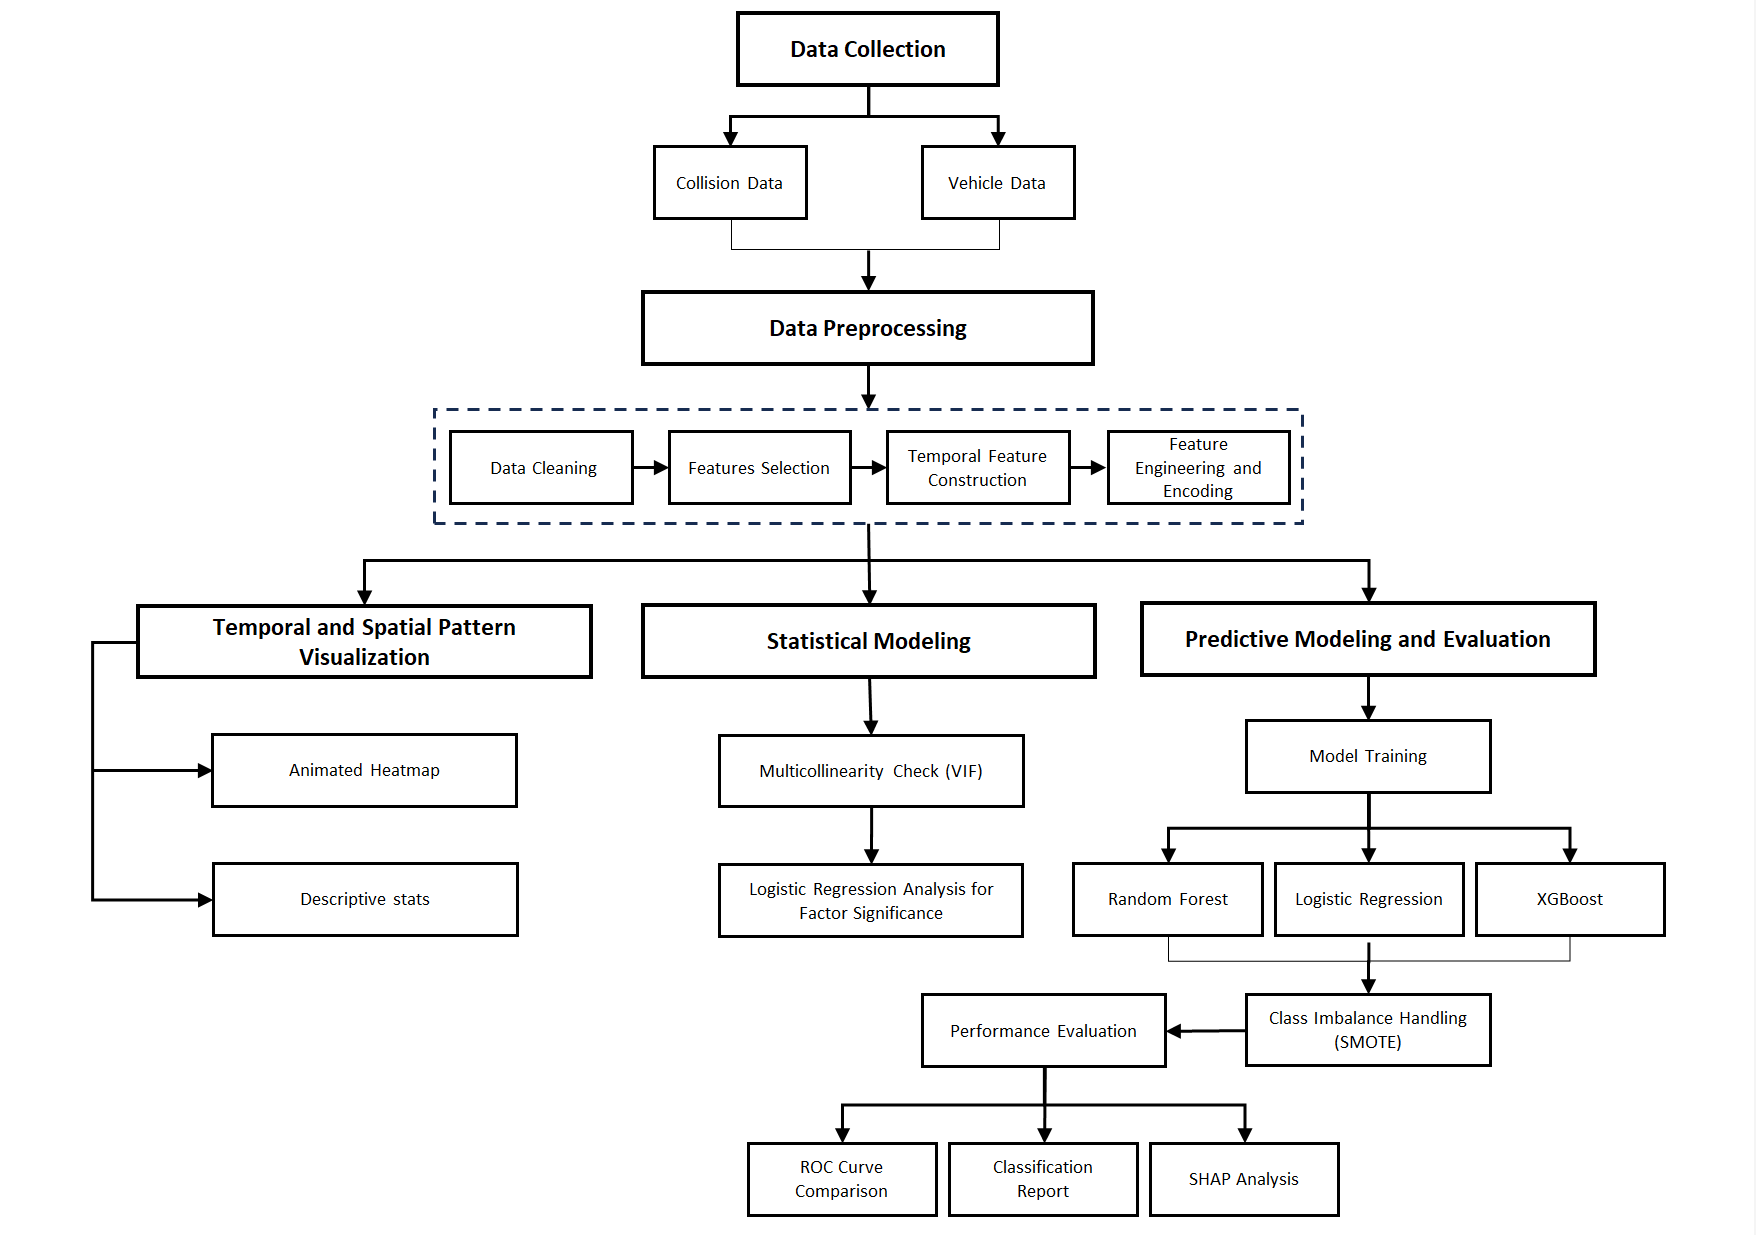

**Figure 1: The flowchart for methodology**

## 5. Results and discussion
[ go back to the top ](#Table-of-contents)

### 5.1 Temporal and Spatial Patterns

To examine whether serious traffic accidents in the UK exhibit discernible temporal and spatial patterns, we conducted both animated and static visual analyses based on the major_incident classification (fatal and serious vs. slight accidents).

#### 5.1.2 Animated Heatmap

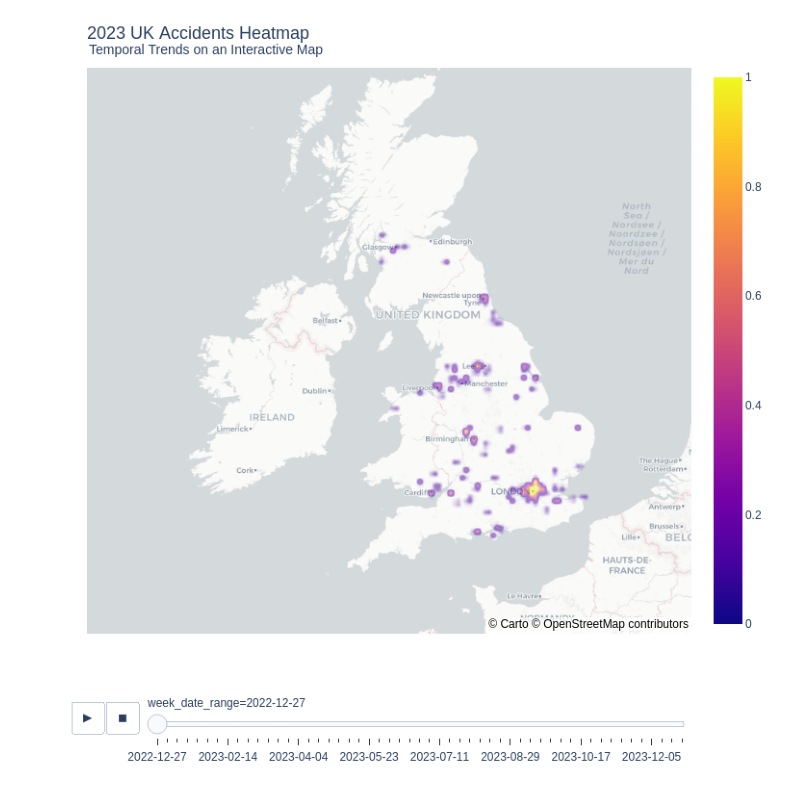

In [9]:
# Adapted from Tanner olstad (2022) 2022 UK Road Safety Data - Visualizations.
# https://kaggle.com/code/tannerolstad0947/2022-uk-road-safety-data-visualizations 

# Load data
url_merged = "https://raw.githubusercontent.com/ukilay/DS/main/merged_cleaned_data.csv"
df = pd.read_csv(url_merged)
# Use the cleaned (but unencoded) dataset for visualization,
# as one-hot encoded data lacks original categorical structure

# Ensure datetime format
df['time_stamp'] = pd.to_datetime(df['time_stamp'])

# Create week-based animation frame
df['week_date_range'] = df['time_stamp'].dt.to_period('W-Mon').dt.start_time
df['week_date_range'] = df['week_date_range'].dt.strftime('%Y-%m-%d')

# Plot
fig = px.density_mapbox(
    df,
    lat='latitude',
    lon='longitude',
    opacity=0.5,
    radius=4,
    animation_frame='week_date_range',
    mapbox_style='carto-positron',
    category_orders={
        'week_date_range': list(np.sort(df['week_date_range'].unique()))
    },
    zoom=4.6,
    center=dict(lat=54.059623, lon=-4.451280)
)

fig.update_layout(
    height=800,
    width=800,
    title_text='2023 UK Accidents Heatmap',
    title_x=0.1,
    title_font=dict(size=18)
)

fig.add_annotation(
    text='Temporal Trends on an Interactive Map',
    xref='paper', yref='paper',
    x=0, y=1.05,
    showarrow=False,
    font=dict(size=14)
)

# ===== Why Two Visualizations? =====
# The animated density map below is designed to capture temporal trends
# in traffic accidents,showing how accident locations change 
# week by week throughout the year.

# This dynamic visualization offers more analytical value than 
# a static annual heatmap, as it helps reveal temporal clusters 
# that a yearly aggregated plot would obscure.

# However, Plotly interactive figures like this one cannot be 
# embedded into exported PDFs from Jupyter Notebook. 
# To ensure the visual content is still accessible when submitting 
# or printing the notebook, a static version of the 
# first animation frame is generated and displayed before
# the interactive map. This allows you to view at least one 
# representative frame even in non-interactive formats.

# In summary:
# The static heatmap ensures compatibility with PDF export.
# The dynamic heatmap better supports **spatiotemporal analysis**,
# which aligns with RQ1 of this study.

import plotly.io as pio
from PIL import Image as PILImage

pio.write_image(fig, "uk_accident_heatmap.png", width=800, height=800)

img = PILImage.open("uk_accident_heatmap.png")
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.tight_layout()
plt.show()

fig.show()

The animated heatmap reveals strong seasonality and weekly variability in accident density, with notable concentration in densely populated regions such as London, the West Midlands, and Greater Manchester. This spatial pattern remains broadly consistent over time, although intensity fluctuates weekly.

#### 5.1.2 Accident Distribution 

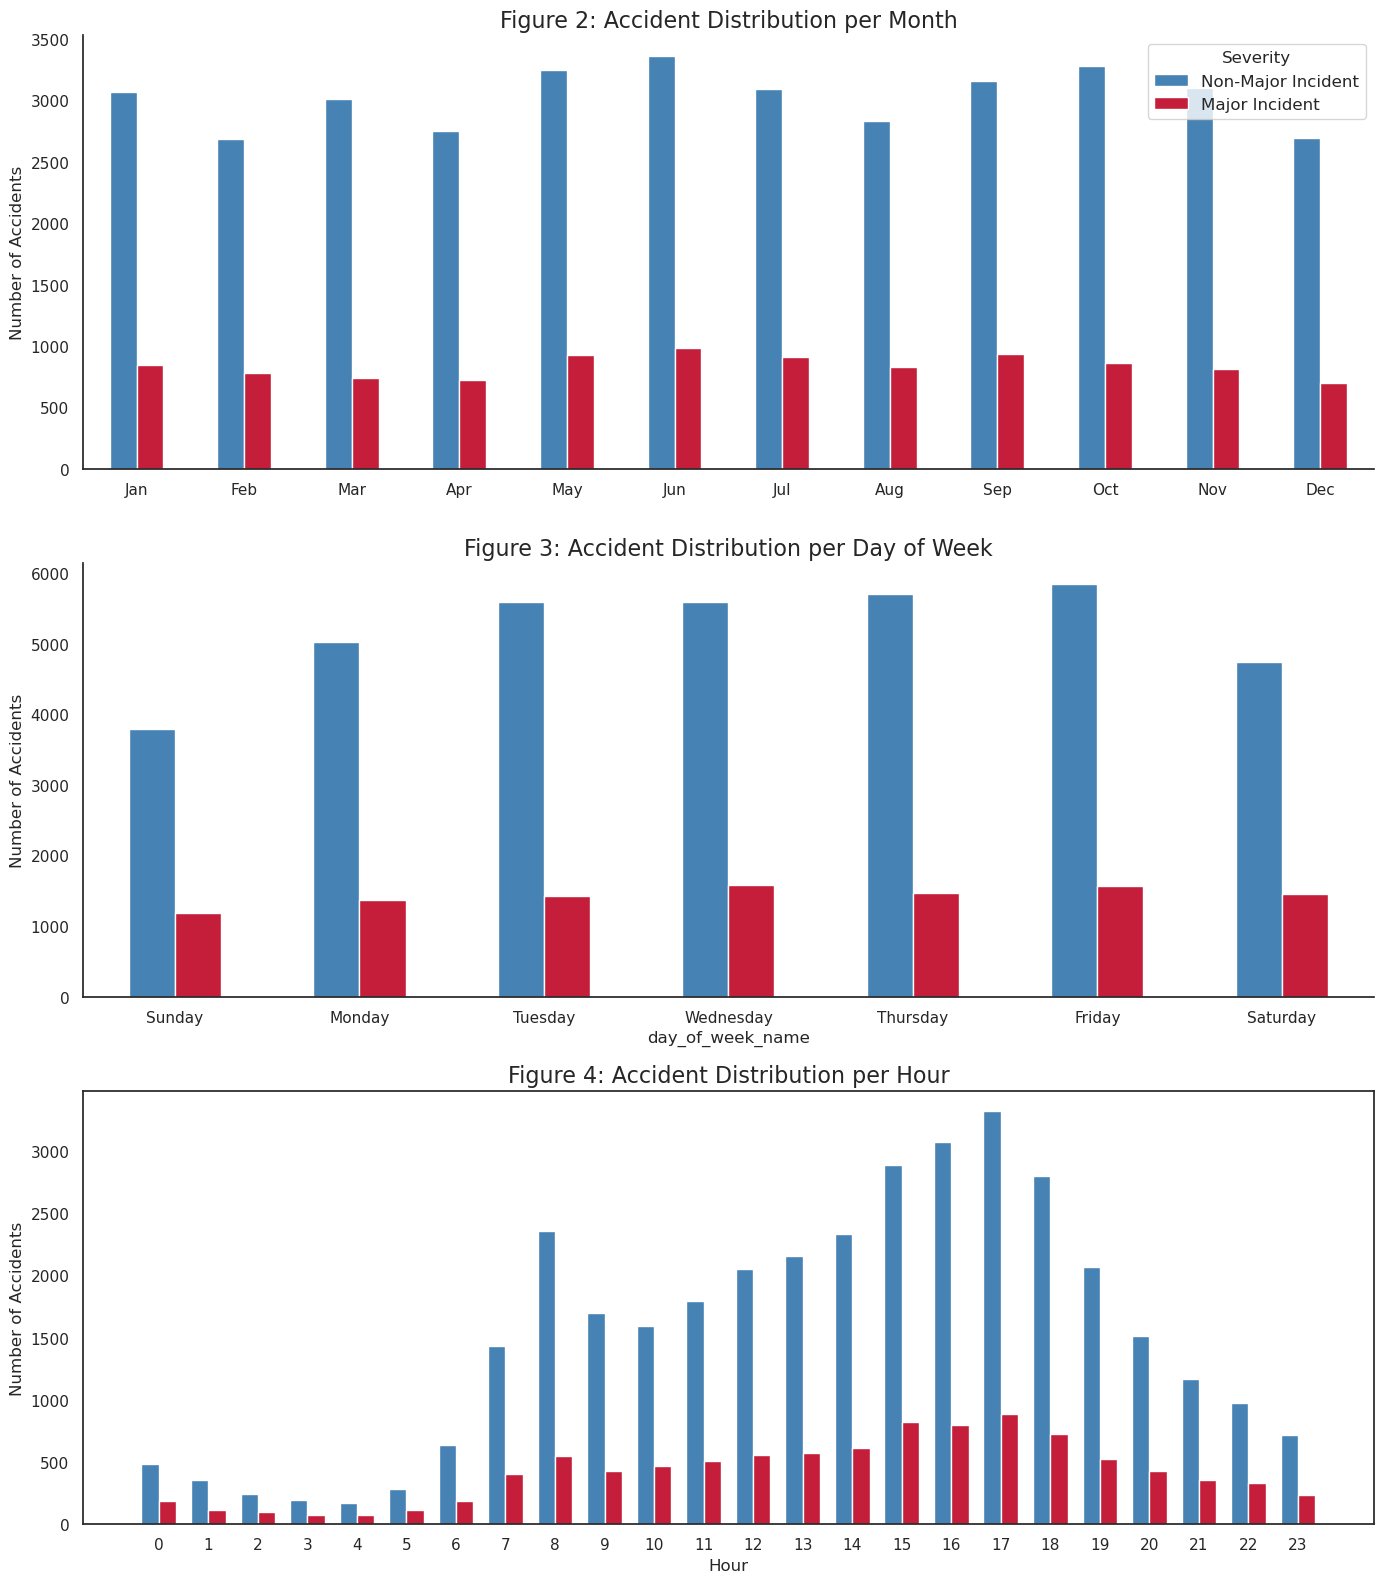

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style and color palette
sns.set(style="white")
colors = {0: "#4682B4", 1: "#C41E3A"}  # steel blue and crimson

# Create subplots for monthly, daily, and hourly patterns
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=False)

# ---- (1) Month ----
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly = merged.groupby(["month", "major_incident"]).size().unstack(fill_value=0)
monthly.index = month_labels
monthly.columns = ["Non-Major Incident", "Major Incident"]
monthly.plot(kind='bar', stacked=False, color=[colors[0], colors[1]], ax=axes[0])
axes[0].set_title("Figure 2: Accident Distribution per Month", fontsize=16)
axes[0].set_ylabel("Number of Accidents")
axes[0].legend().set_visible(False)
axes[0].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[0])

# ---- (2) Day of Week ----
day_labels = {
    1: "Sunday", 2: "Monday", 3: "Tuesday", 4: "Wednesday",
    5: "Thursday", 6: "Friday", 7: "Saturday"
}
merged["day_of_week_name"] = merged["day_of_week"].map(day_labels)
daily = merged.groupby(["day_of_week_name", "major_incident"]).size().unstack(fill_value=0)
daily = daily.reindex(["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"])
daily.plot(kind='bar', stacked=False, color=[colors[0], colors[1]], ax=axes[1])
axes[1].set_title("Figure 3: Accident Distribution per Day of Week", fontsize=16)
axes[1].set_ylabel("Number of Accidents")
axes[1].legend().set_visible(False)
axes[1].tick_params(axis='x', rotation=0)
sns.despine(ax=axes[1])

# ---- (3) Hour ----
hourly = merged.groupby(['hour', 'major_incident']) \
                .size() \
                .unstack(fill_value=0) \
                .sort_index()
width = 0.35
x = hourly.index.astype(int)

axes[2].bar(x - width/2, hourly[0], width=width, label="Non-Major Incident", color=colors[0])
axes[2].bar(x + width/2, hourly[1], width=width, label="Major Incident", color=colors[1])

axes[2].set_title("Figure 4: Accident Distribution per Hour", fontsize=16)
axes[2].set_xlabel("Hour", fontsize=12)
axes[2].set_ylabel("Number of Accidents", fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(x)
axes[2].tick_params(axis='x', rotation=0)

# Add legend only once
axes[0].legend(title="Severity", loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

Descriptive bar charts (Figures 2–4) further support temporal trends. Accident counts peak during summer months (particularly June) and are relatively lower in winter. Weekday analysis shows the highest number of accidents occurs on Thursdays and Fridays, with a slight dip over weekends. Hourly distribution demonstrates a sharp increase in incidents during morning (7–9 AM) and evening (4–6 PM) rush hours, aligning with commuter traffic patterns. Notably, while overall volumes differ, the temporal distribution between major and non-major incidents follows a similar shape, though major incidents appear more concentrated in high-risk periods.

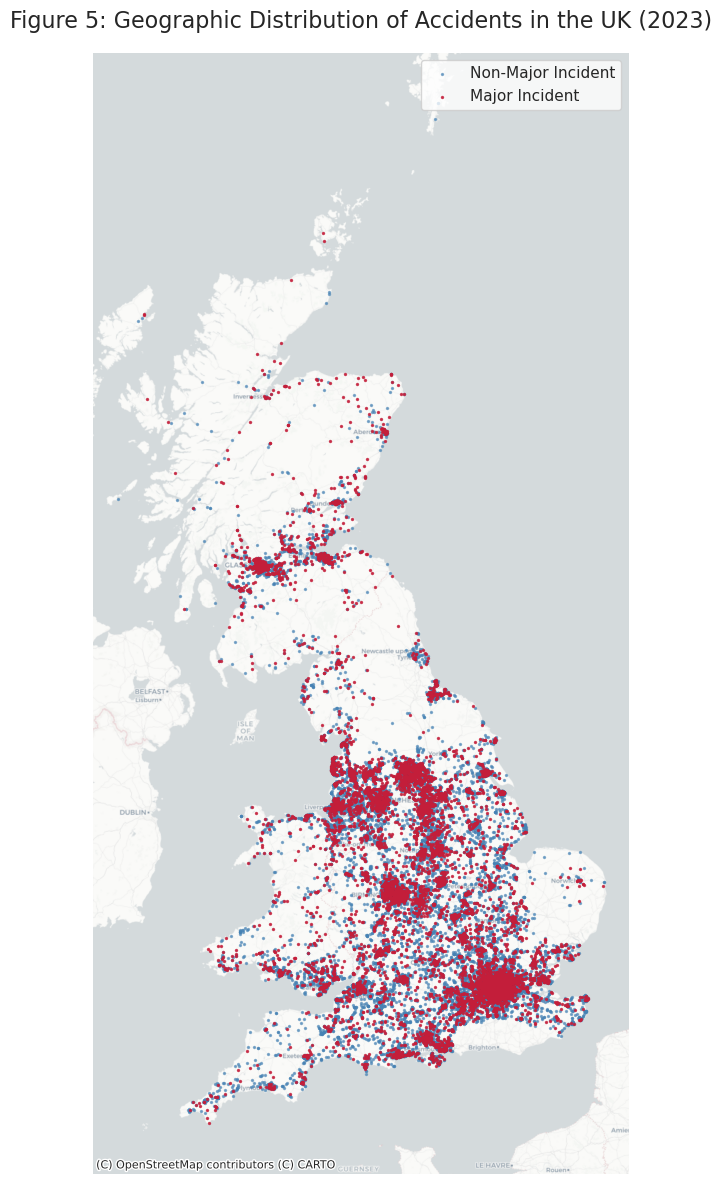

In [11]:
# Load data
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

# Reproject to Web Mercator for contextily basemap
gdf = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
gdf[gdf["major_incident"] == 0].plot(ax=ax, markersize=2, color="#4682B4", label="Non-Major Incident", alpha=0.6)
gdf[gdf["major_incident"] == 1].plot(ax=ax, markersize=2, color="#C41E3A", label="Major Incident", alpha=0.8)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Final touches
ax.set_title("Figure 5: Geographic Distribution of Accidents in the UK (2023)", fontsize=16)
ax.set_axis_off()
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

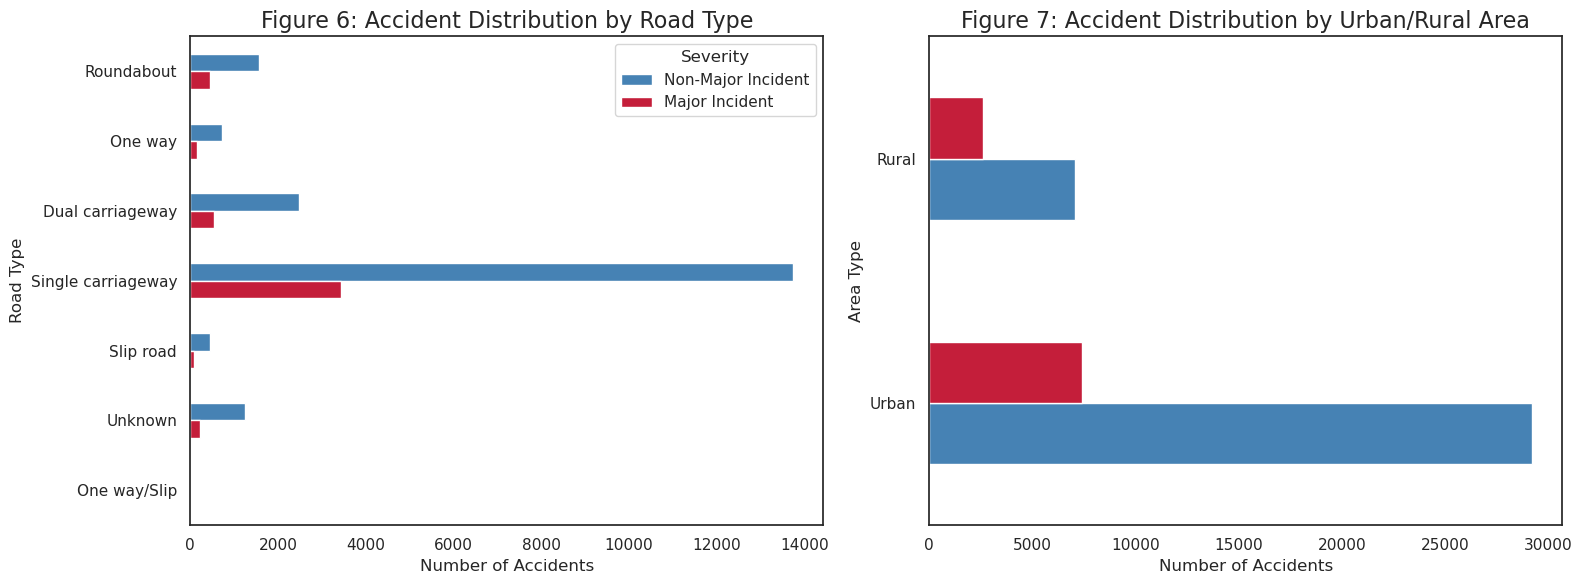

In [12]:
# Define readable labels for road_type
road_labels = {
    1: "Roundabout", 2: "One way", 3: "Dual carriageway",
    6: "Single carriageway", 7: "Slip road", 9: "Unknown",
    12: "One way/Slip"
}
merged["road_type_label"] = df["road_type"].map(road_labels)

# Prepare data
road_grouped = merged.groupby(["road_type_label", "major_incident"]).size().unstack(fill_value=0)
road_grouped = road_grouped.reindex(road_labels.values())  # Ensure consistent order

# Urban/rural mapping
area_labels = {1: "Urban", 2: "Rural", 3: "Unallocated"}
merged["urban_rural_label"] = merged["urban_or_rural_area"].map(area_labels)

# Group urban/rural data
area_grouped = merged.groupby(["urban_rural_label", "major_incident"]).size().unstack(fill_value=0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Road Type Plot
road_grouped.plot(kind='barh', stacked=False, color=["#4682B4", "#C41E3A"], ax=axes[0])
axes[0].set_title("Figure 6: Accident Distribution by Road Type", fontsize=16)
axes[0].set_xlabel("Number of Accidents")
axes[0].set_ylabel("Road Type")
axes[0].legend(["Non-Major Incident", "Major Incident"], title="Severity")
axes[0].invert_yaxis()

# Urban/Rural Plot
area_grouped.plot(kind='barh', stacked=False, color=["#4682B4", "#C41E3A"], ax=axes[1])
axes[1].set_title("Figure 7: Accident Distribution by Urban/Rural Area", fontsize=16)
axes[1].set_xlabel("Number of Accidents")
axes[1].set_ylabel("Area Type")
axes[1].legend().set_visible(False)

plt.tight_layout()
plt.show()

Static spatial mapping (Figure 5) shows that major incidents are more densely distributed in central and southern England, particularly urban corridors. When comparing distributions by road characteristics (Figure 6-7), both types of incidents are overwhelmingly concentrated on single carriageways and in urban areas. However, major incidents make up a relatively larger share on rural roads compared to non-major incidents, suggesting a potential risk factor associated with road environment.

### 5.2 Factors Influencing the Severity of Road Traffic Incidents

#### 5.2.1 Multicollinearity Diagnosis using VIF

To ensure the robustness of the regression model, multicollinearity diagnostics were conducted using the Variance Inflation Factor (VIF). Initial checks revealed severe multicollinearity among several features. These variables were iteratively removed in two rounds of VIF filtering, each time eliminating predictors with VIF values exceeding the conventional threshold of 10.

Due to the large size and high dimensionality of the dataset, VIF computation was computationally expensive, requiring significant processing time. As a result, only the final round of VIF results is presented in this report. The remaining features all had VIF values well below the threshold, indicating that multicollinearity was sufficiently addressed.

In [13]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Automatically select and clean features based on prefixes, and remove multicollinearity using VIF

relevant_prefixes = [
    "road_type", "speed_limit", "light_conditions",
    "weather_conditions", "road_surface_conditions",
    "vehicle_manoeuvre", "sex_of_driver", "age_band_of_driver"
]

selected_columns = [
    col for col in df_encoded.columns
    if any(col.startswith(prefix) for prefix in relevant_prefixes)
]

X = df_encoded[selected_columns]
X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = X.astype(float)

def calculate_vif(X, threshold=10.0):
    dropped = True
    while dropped:
        dropped = False
        X_const = sm.add_constant(X)
        vif = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns
        )
        max_vif = vif.drop("const").max()
        if max_vif > threshold:
            drop_feature = vif.drop("const").idxmax()
            print(f"Dropping '{drop_feature}' due to high VIF: {max_vif:.2f}")
            X = X.drop(columns=[drop_feature])
            dropped = True
    return X, vif.drop("const").sort_values(ascending=False)

X_reduced, final_vif = calculate_vif(X)

print("Top VIF Features After Auto Removal:")
print(final_vif.head(20))

Dropping 'age_band_of_driver_6.0' due to high VIF: 1092.46
Dropping 'vehicle_manoeuvre_18.0' due to high VIF: 21.92
Top VIF Features After Auto Removal:
road_type_6                  2.780713
road_surface_conditions_9    2.348110
weather_conditions_9         2.111852
road_type_3                  2.079017
road_type_9                  1.940558
road_surface_conditions_2    1.839625
weather_conditions_2         1.726378
vehicle_manoeuvre_99.0       1.709771
speed_limit_30               1.671985
road_surface_conditions_3    1.526902
weather_conditions_3         1.477757
age_band_of_driver_7.0       1.440669
speed_limit_40               1.395991
speed_limit_60               1.385574
age_band_of_driver_8.0       1.377520
road_type_2                  1.335596
age_band_of_driver_5.0       1.303573
age_band_of_driver_9.0       1.299765
age_band_of_driver_4.0       1.230456
vehicle_manoeuvre_9.0        1.228555
dtype: float64


#### 5.2.2 Logistic Regression Analysis

In [14]:
import statsmodels.api as sm
from statsmodels.tools import add_constant

y = df_encoded["major_incident"].astype(int)
X = sm.add_constant(X_reduced)

logit_model = sm.Logit(y, X)
result = logit_model.fit(method="lbfgs", maxiter=100, disp=0)

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         major_incident   No. Observations:                46315
Model:                          Logit   Df Residuals:                    46259
Method:                           MLE   Df Model:                           55
Date:                Mon, 21 Apr 2025   Pseudo R-squ.:                 0.05845
Time:                        04:23:04   Log-Likelihood:                -22793.
converged:                       True   LL-Null:                       -24208.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.4483      0.058    -24.803      0.000      -1.563      -1.334
road_type_2                   0.2808      0.088      3.196      0.001       0.109       0.453
road_type_3                   0.2443      0.055      4.453      0.000       0.137       0.352
road_type_6                   0.3426      0.045      7.551      0.000       0.254       0.432
road_type_7                   0.1615      0.103      1.565      0.118      -0.041       0.364
road_type_9                   0.0151      0.133      0.114      0.909      -0.245       0.275
speed_limit_30               -0.0436      0.032     -1.383      0.167      -0.105       0.018
speed_limit_40                0.0695      0.048      1.442      0.149      -0.025       0.164
speed_limit_50                0.2201      0.065      3.372      0.001       0.092       0.348
speed_limit_60                0.2387      0.050      4.759      0.000       0.140       0.337
speed_limit_70                0.0999      0.100      1.003      0.316      -0.095       0.295
light_conditions_4            0.1244      0.028      4.372      0.000       0.069       0.180
light_conditions_5            0.3736      0.134      2.787      0.005       0.111       0.636
light_conditions_6            0.1459      0.073      1.995      0.046       0.003       0.289
light_conditions_7            0.1849      0.109      1.700      0.089      -0.028       0.398
weather_conditions_2         -0.0477      0.047     -1.025      0.305      -0.139       0.043
weather_conditions_3         -0.1070      0.244     -0.439      0.660      -0.584       0.370
weather_conditions_4          0.2091      0.117      1.783      0.075      -0.021       0.439
weather_conditions_5         -0.0228      0.117     -0.195      0.846      -0.252       0.206
weather_conditions_6         -0.2504      0.799     -0.313      0.754      -1.817       1.316
weather_conditions_7         -0.2824      0.245     -1.154      0.249      -0.762       0.197
weather_conditions_8         -0.1243      0.075     -1.647      0.100      -0.272       0.024
weather_conditions_9         -0.4020      0.108     -3.706      0.000      -0.615      -0.189
road_surface_conditions_2    -0.0650      0.036     -1.823      0.068      -0.135       0.005
road_surface_conditions_3    -0.0607      0.333     -0.182      0.856      -0.714       0.593
road_surface_conditions_4    -0.2599      0.123     -2.105      0.035      -0.502      -0.018
road_surface_conditions_5    -1.2334      0.747     -1.651      0.099      -2.698       0.231
road_surface_conditions_9    -0.5609      0.215     -2.607      0.009      -0.983      -0.139
vehicle_manoeuvre_2.0        -0.1769      0.193     -0.916      0.360      -0.555       0.202
vehicle_manoeuvre_3.0        -1.0371      0.097    -10.685      0.000      -1.227      -0.847
vehicle_manoeuvre_4.0        -0.5110      0.065     -7.823      0.000      -0.639      -0.383
vehicle_manoeuvre_5.0        -0.1363      0.0

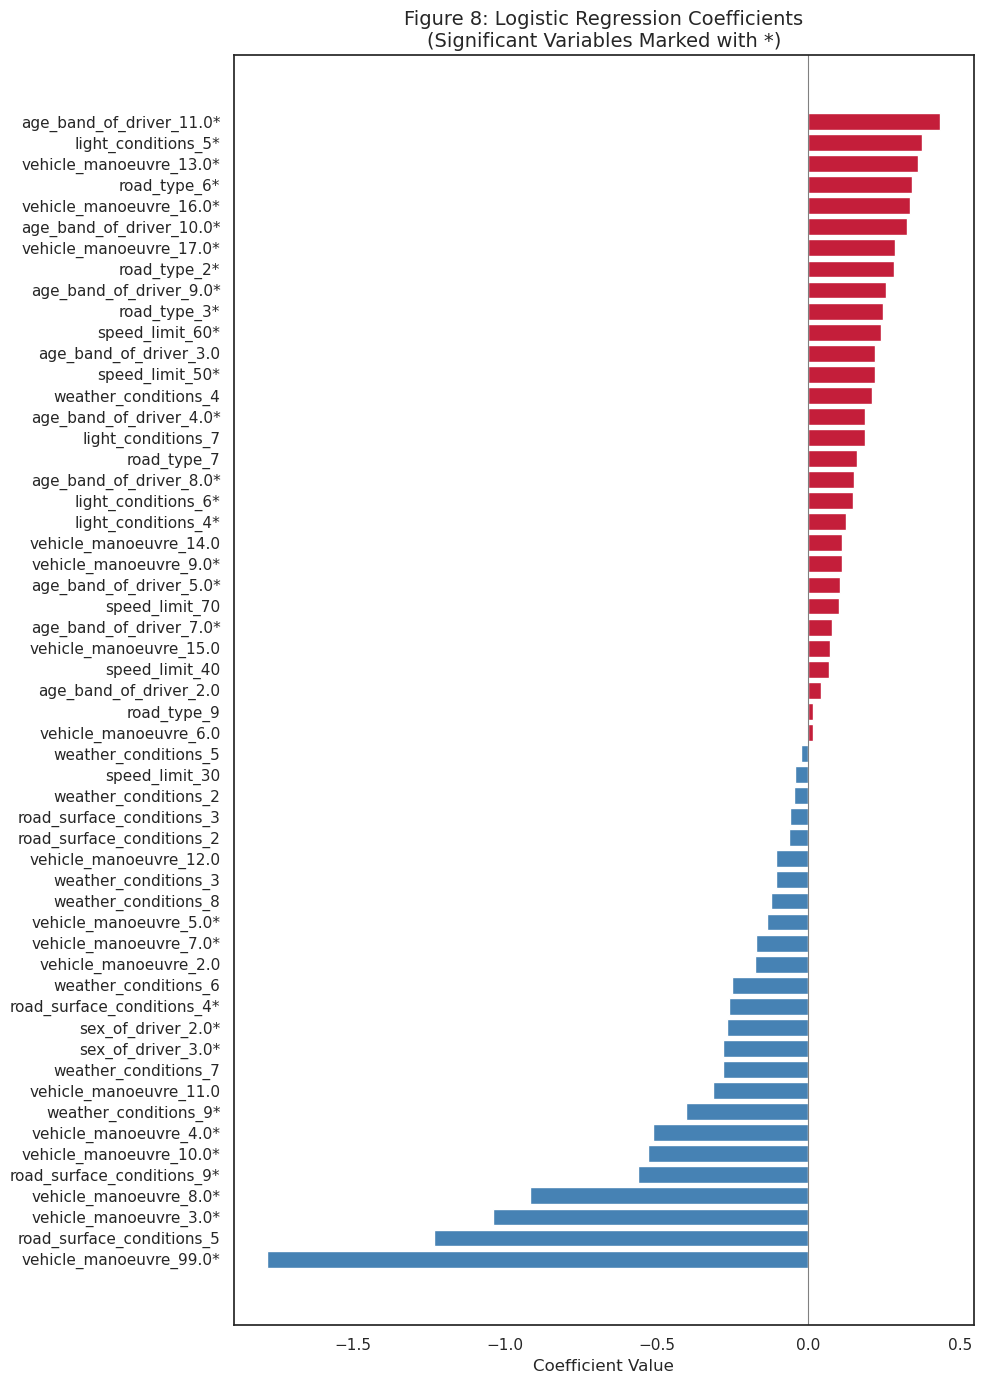

In [15]:
# Visualize model coefficients after logistic regression fit
# Positive coefficients in red, negative in blue, sorted by magnitude

params = result.params.drop("const")
pvalues = result.pvalues.drop("const")

colors = ["#C41E3A" if coef > 0 else "#4682B4" for coef in params]

labels = [f"{var}*" if p < 0.05 else var for var, p in zip(params.index, pvalues)]

coef_df = params.to_frame(name="coef")
coef_df["color"] = colors
coef_df["label"] = labels
coef_df = coef_df.sort_values("coef", ascending=False)

plt.figure(figsize=(10, 14))
for i, (label, coef, color) in enumerate(zip(coef_df["label"], coef_df["coef"], coef_df["color"])):
    plt.barh(label, coef, color=color)

plt.axvline(0, color='gray', linewidth=0.8)
plt.title("Figure 8: Logistic Regression Coefficients\n(Significant Variables Marked with *)", fontsize=14)
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

The logistic regression analysis identified several environmental and behavioral factors that were significantly associated with the likelihood of a major traffic incident. Among environmental conditions, road layout had a strong effect: compared to the reference category, roundabouts (road_type_3: β = 0.24, p < 0.001) and single carriageways (road_type_6: β = 0.34, p < 0.001) were significantly more likely to be associated with severe accidents. Higher speed limits also exhibited positive associations with severity, particularly at 50 mph (β = 0.22, p = 0.001) and 60 mph (β = 0.24, p < 0.001).

Lighting conditions also played a notable role: accidents occurring under darkness without street lighting (light_conditions_5) were significantly more likely to result in major incidents (β = 0.37, p = 0.005). Weather effects were mixed, with some categories, such as fog or mist (weather_conditions_9), associated with a lower likelihood of severe outcomes (β = −0.40, p < 0.001), potentially reflecting more cautious driving in poor visibility.

Behavioral variables—particularly vehicle manoeuvre—were strongly associated with accident severity. Compared to the baseline manoeuvre (i.e., driving straight ahead), high-risk actions such as turning right (manoeuvre_13.0: β = 0.36, p < 0.001), reversing (manoeuvre_10.0: β = −0.53, p < 0.001), and performing a U-turn (manoeuvre_16.0: β = 0.34, p < 0.001) showed significant effects in either increasing or reducing the probability of a major incident.

Driver demographics also contributed: being female was associated with a lower likelihood of major incidents (sex_of_driver_2.0: β = −0.27, p < 0.001), while older drivers—especially those over 75 years (age_band_of_driver_11.0: β = 0.43, p < 0.001)—were more likely to be involved in severe accidents.

The model showed acceptable fit (Pseudo R² = 0.058, Log-Likelihood = −22,793, p < 0.001), indicating that these environmental and behavioral variables collectively explain a meaningful portion of the variance in accident severity.

### 5.3 Predicting the Severity of Traffic Accidents Using Machine Learning

To address RQ3, we tested three models—Logistic Regression, Random Forest, and XGBoost—to predict accident severity based on environmental and behavioral factors. Given the class imbalance (major incidents comprising ~22% of cases), we applied SMOTE to oversample the minority class. Without resampling, models—particularly logistic regression—showed near-zero recall for major incidents, limiting their practical value. SMOTE was therefore crucial for improving model sensitivity to severe cases.

#### 5.3.1 ROC Curve Comparison

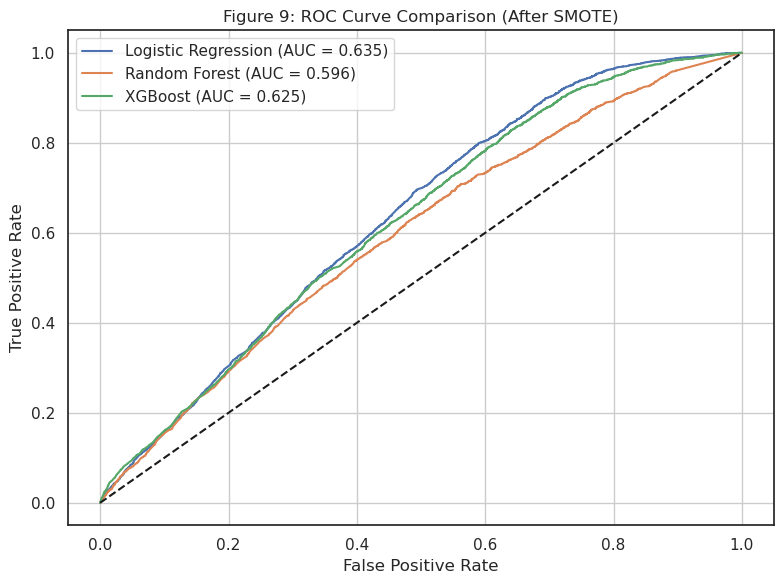

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

X = X_reduced.copy()
y = df_encoded["major_incident"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "auc": auc,
        "report": report
    }

#  ROC 
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 9: ROC Curve Comparison (After SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

As shown in Figure 9, all models showed moderate predictive ability, with Logistic Regression achieving the highest AUC (0.635), followed by XGBoost (0.625) and Random Forest (0.596). Although the AUC scores appear low, such values are common in traffic accident studies—especially when using only environmental and behavioral features (Ghandour, Hammoud and Al-Hajj, 2020; Silva, Andrade and Ferreira, 2020). This is partly due to the imbalanced nature of the data (major incidents account for only ~22%) and the absence of key unobserved factors like fatigue, alcohol use, or collision dynamics.

#### 5.3.2  Classification Metrics by Severity

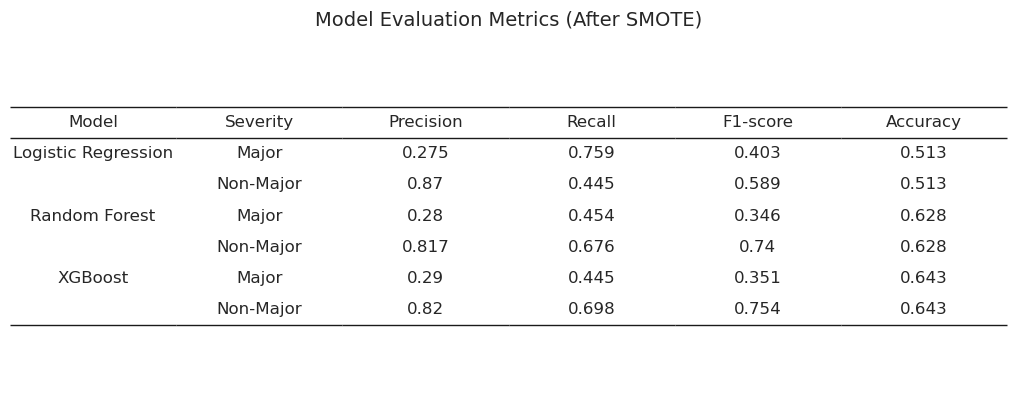

In [17]:
# Build Formatted DataFrame
rows = []
for model_name, res in results.items():
    for label, severity in zip(["1", "0"], ["Major", "Non-Major"]):
        row = {
            "Model": model_name,
            "Severity": severity,
            "Precision": res["report"][label]["precision"],
            "Recall": res["report"][label]["recall"],
            "F1-score": res["report"][label]["f1-score"],
            "Accuracy": res["report"]["accuracy"]
        }
        rows.append(row)

df_results = pd.DataFrame(rows)
df_results = df_results[["Model", "Severity", "Precision", "Recall", "F1-score", "Accuracy"]]


plt.rcParams.update({'font.size': 1})

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText=df_results.round(3).values,
    colLabels=df_results.columns,
    cellLoc='center',
    loc='center'
)

for (row, col), cell in table.get_celld().items():
    cell.visible_edges = ''
    if row == 0:
        cell.visible_edges = 'BT'
    if row == len(df_results):
        cell.visible_edges = 'B'
    if col == 0 and row in [2, 4, 6]:
        cell.set_facecolor('white')
        cell.get_text().set_text('')


table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)
plt.title("Model Evaluation Metrics (After SMOTE)", fontsize=14, pad=0)
plt.tight_layout()
plt.show()

The table above presents a detailed comparison of the classification performance across models and severity classes following the application of SMOTE. Logistic Regression achieved the highest recall for major incidents (0.759), indicating strong sensitivity in identifying severe cases. However, this was accompanied by low precision (0.275) and a relatively modest F1-score (0.403) for the positive class. Random Forest, despite yielding the highest overall accuracy (0.628), demonstrated limited effectiveness in detecting major incidents, with a recall of 0.454 and an F1-score of 0.346.

In contrast, XGBoost demonstrated the most balanced performance across evaluation metrics. It achieved slightly higher precision (0.290) than Logistic Regression and a comparable F1-score for major incidents (0.351), while maintaining strong predictive performance for non-major incidents (F1 = 0.754). Taken together, these results suggest that Logistic Regression may be more appropriate in safety-critical contexts where minimizing false negatives is essential, whereas XGBoost may be preferable when a more even tradeoff between precision and recall is desired.

#### 5.3.3 Feature Importance (SHAP Analysis)

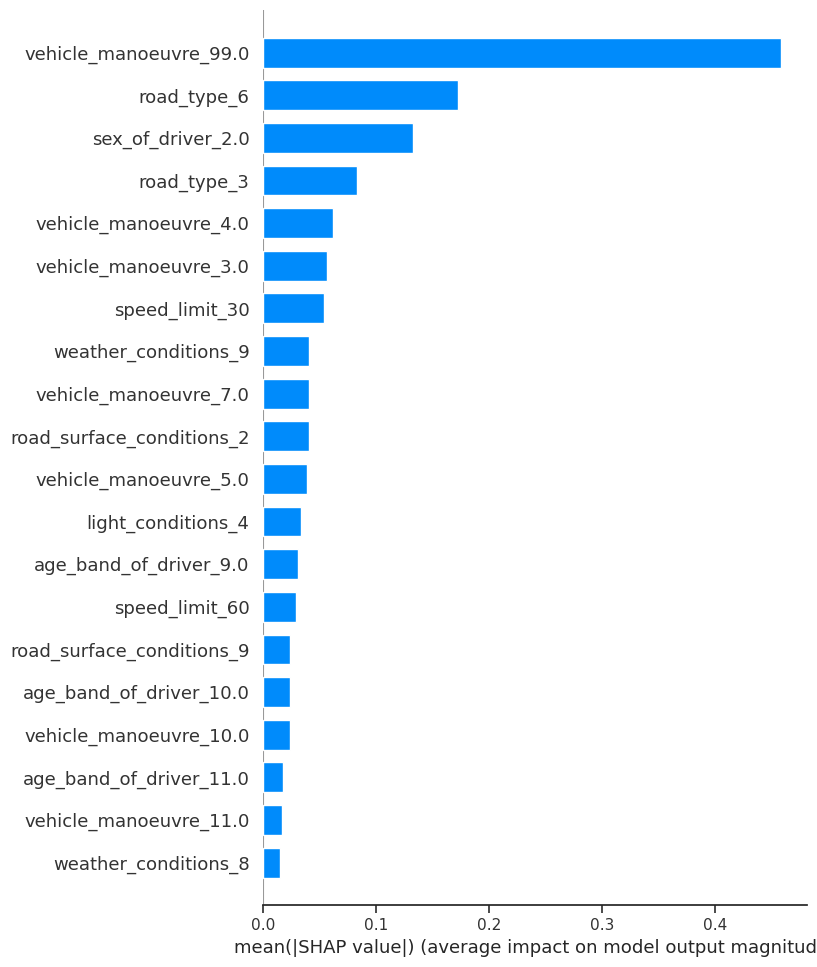

In [18]:
import shap
best_model = results["Logistic Regression"]["model"]
explainer = shap.LinearExplainer(best_model, X_train_resampled, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

To interpret feature contributions in the final model, SHAP values were applied to the Logistic Regression classifier. The SHAP summary plot highlighted several influential predictors. Notably, vehicle_manoeuvre_99.0 (unknown) ranked as the most important variable, suggesting that unspecified or ambiguous driving behavior may correspond to more severe accidents. The high predictive value of the 'unknown' maneuver category may indicate that such records correspond to unstructured or chaotic driving scenarios, or alternatively, highlight systematic data quality issues in crash reporting. Other key features included road_type_6 (single carriageway), road_type_3 (roundabouts), and high-risk behaviors such as U-turns, reversing, and overtaking, reinforcing the central role of behavioral dynamics and road context.

While missing values were removed during preprocessing, certain “unknown” categories—such as driver maneuver and weather condition—were retained to maintain sample size. Their high model importance implies that ambiguity itself may carry risk-relevant information. However, this reliance on ill-defined categories introduces interpretability challenges (Imprialou and Quddus, 2019). This should be acknowledged as a limitation, and future traffic datasets would benefit from more consistent and detailed recording of driver behavior and environmental conditions.

## 6. Conclusion

[[ go back to the top ]](#Table-of-contents)

**RQ1**: Serious accidents showed distinct spatiotemporal patterns, with higher incidence during weekday peak hours and on single carriageways in urban areas. These trends support the need for targeted safety interventions in both time and space. These findings can inform targeted interventions such as time-specific traffic control and road safety enhancements on vulnerable road types.

**RQ2**: Logistic regression revealed several significant environmental and behavioral predictors of accident severity. Factors such as poor lighting conditions, high speed limits, and complex maneuvers like U-turns and reversing were associated with increased risk. Female drivers were less likely to be involved in severe accidents, while older drivers—especially those aged 75 and above—were more frequently associated with higher severity outcomes.

**RQ3**: Among the models tested, Logistic Regression yielded the highest recall for major incidents, while XGBoost offered more balanced predictive performance. Applying SMOTE improved sensitivity to severe cases across all models. SHAP analysis further highlighted the importance of maneuver type, road layout, and speed, although the presence of “unknown” categories among top predictors suggests both data limitations and potential risks associated with ambiguous reporting.

While the overall predictive performance of the models was moderate, the results confirm that both environmental and behavioral variables hold meaningful associations with accident severity. In particular, road layout, lighting, speed limits, and driver maneuvers consistently emerged as influential factors. These findings reinforce the potential of data-driven approaches in supporting traffic safety analysis. Future research could build on this work by incorporating more granular behavioral data and exploring temporal dynamics to further improve model accuracy and practical applicability.

## 7. References

[[ go back to the top ]](#Table-of-contents)

Ghandour, A.J., Hammoud, H. and Al-Hajj, S. (2020) ‘Analyzing Factors Associated with Fatal Road Crashes: A Machine Learning Approach’, International Journal of Environmental Research and Public Health, 17(11), p. 4111. Available at: https://doi.org/10.3390/ijerph17114111.

Imprialou, M. and Quddus, M. (2019) ‘Crash data quality for road safety research: Current state and future directions’, Accident Analysis & Prevention, 130, pp. 84–90. Available at: https://doi.org/10.1016/j.aap.2017.02.022.

Pourroostaei Ardakani, S. et al. (2023) ‘Road Car Accident Prediction Using a Machine-Learning-Enabled Data Analysis’, Sustainability, 15(7), p. 5939. Available at: https://doi.org/10.3390/su15075939.

Savolainen, P.T. et al. (2011) ‘The statistical analysis of highway crash-injury severities: A review and assessment of methodological alternatives’, Accident Analysis & Prevention, 43(5), pp. 1666–1676. Available at: https://doi.org/10.1016/j.aap.2011.03.025.

Silva, P.B., Andrade, M. and Ferreira, S. (2020) ‘Machine learning applied to road safety modeling: A systematic literature review’, Journal of Traffic and Transportation Engineering (English Edition), 7(6), pp. 775–790. Available at: https://doi.org/10.1016/j.jtte.2020.07.004.

Sufian, M.A., Varadarajan, J. and Niu, M. (2024) ‘RETRACTED: Enhancing prediction and analysis of UK road traffic accident severity using AI: Integration of machine learning, econometric techniques, and time series forecasting in public health research’, Heliyon, 10(7), p. e28547. Available at: https://doi.org/10.1016/j.heliyon.2024.e28547.

Sze, N.N. and Wong, S.C. (2007) ‘Diagnostic analysis of the logistic model for pedestrian injury severity in traffic crashes’, Accident Analysis & Prevention, 39(6), pp. 1267–1278. Available at: https://doi.org/10.1016/j.aap.2007.03.017.